# Protocol resting

## Import raw data to structured json data

Import raw data from /datasets/raw to structured json data in /datasets/restings. In my case I had .txt raw data from Elite HRV export Data.

In [1]:
from scripts.import_rr import import_all

## default output_dir is /datasets/resting

if __name__ == "__main__":
    import_all(output_dir = "datasets/resting")

Skipped (already exists): 2026-04-24 07-52-36.json


## Pipeline Score, RMSSD, ...

Print for all file json export with the date, and the differents stats from time domain (RMSSD, SDNN, PNN50 and mean HR)

In [4]:
from __future__ import annotations

import json
import glob

import numpy as np
import matplotlib.pyplot as plt

from signals.rr import RRSeries
from protocols.resting import resting_hrv
from analytics.baseline import Baseline
from analytics.scoring import readiness_score_oura


path="datasets/resting/*.json"

files = sorted(glob.glob(path))

dates = []
rmssd_values = []
scores = []

baseline = Baseline()

for file in files:
    with open(file) as f:
        data = json.load(f)

    rr = RRSeries(data["rr_intervals"])
    result = resting_hrv(rr)

    baseline.add(result)

    score = readiness_score_oura(result, baseline)

    dates.append(data["date"])
    rmssd_values.append(result.rmssd)
    scores.append(score)

    print({
            "date": data["date"],
            "rmssd_value": result.rmssd,
            "sdnn_value": result.sdnn,
            "pnn50_value": result.pnn50,
            "mean_hr_value": result.mean_hr,
            "score": score,
        })

{'date': '2026-04-24 07-52-36', 'rmssd_value': 78.45952174034798, 'sdnn_value': 95.90436102471041, 'pnn50_value': 17.55485893416928, 'mean_hr_value': 57.896371525840784, 'score': 50.0}


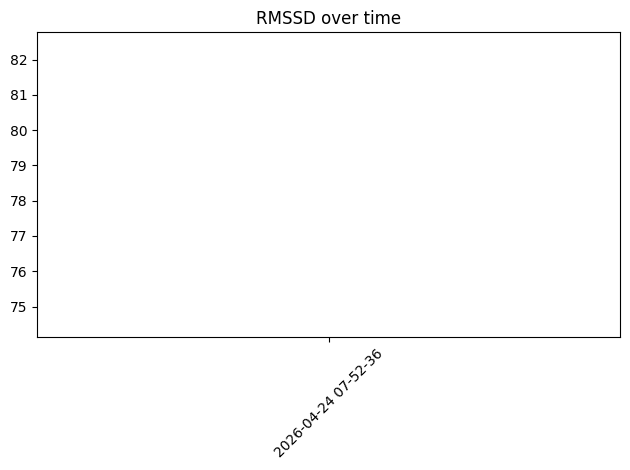

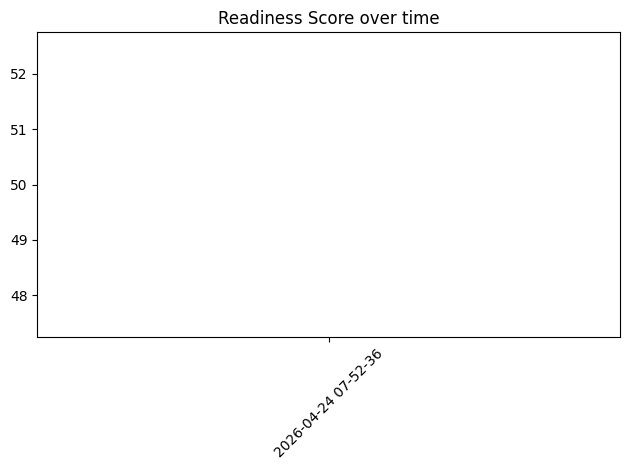

In [2]:
from visualization.plot import plot_resting_evolution

plot_resting_evolution()